In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.sparse.linalg import expm_multiply, expm
from scipy.sparse import diags
from utils import *
from ionq_circuit_utils import *

from os import getenv
from os.path import join
import json
import hashlib
import time

import networkx as nx
from random import shuffle, seed

import requests

from braket.circuits import Circuit
from braket.devices import LocalSimulator
from braket.aws import AwsDevice, AwsQuantumTask

# from simuq import QSystem
# from simuq import Qubit
# from simuq.ionq import IonQProvider, IonQAPICircuit

from qiskit import QuantumCircuit, transpile

from dotenv import load_dotenv
load_dotenv()

True

In [2]:
IONQ_API_KEY = getenv('IONQ_API_KEY')

# Helper functions

In [3]:
# Sends job and returns job_id
def send_job(job):
    headers = {
        "Authorization": f"apiKey {IONQ_API_KEY}",
        "Content-Type": "application/json"
    }
    req = requests.post("https://api.ionq.co/v0.3/jobs", json=job, headers=headers)
    try:
        job_id = json.loads(req.content)['id']
    except KeyError:
        print(req.content)
        raise KeyError(f"Error sending job. Error message: {req.content['''message''']}")
    return job_id

In [4]:
def get_ionq_single_job_result(job_id, codewords, use_error_mitigation=False):
    # Get job
    print("Getting job:", job_id)

    headers = {
        "Authorization": f"apiKey {IONQ_API_KEY}"
    }

    req = requests.get(f"https://api.ionq.co/v0.3/jobs/{job_id}", headers=headers)
    

    status = json.loads(req.content)['status']
    print(f"Job status: {status}")
    if status == "completed":
        
        headers = {
            "Authorization": f"apiKey {IONQ_API_KEY}"
        }
        if use_error_mitigation:
            params = {"sharpen": "true"} # plural voting aggregation
        else:
            params = {"sharpen": "false"}
        req = requests.get(f"https://api.ionq.co/v0.3/jobs/{job_id}/results", headers=headers, params=params)
        results = json.loads(req.content)
        if "error" in results.keys():
            raise AttributeError(results["message"])
        else:
            freq = np.zeros(len(codewords))
            for i in range(len(codewords)):
                if str(codewords[i]) in results.keys():
                    freq[i] = results[str(codewords[i])]
            return freq
    else:
        raise FileNotFoundError("Job not completed")
    
def get_results(job_ids_path, num_time_points, codewords, use_error_mitigation=False):
    with open(job_ids_path, "r") as f:
        job_ids = json.load(f)
        f.close()

    freq = np.zeros((num_time_points, len(codewords)))
    for i, job_id in enumerate(job_ids):

        freq[i] = get_ionq_single_job_result(job_id, codewords, use_error_mitigation)

    return freq

def cancel_job(job_id):
    print("Cancelling job:", job_id)

    headers = {
        "Authorization": f"apiKey {IONQ_API_KEY}"
    }
    r = requests.put(f"https://api.ionq.co/v0.3/jobs/{job_id}/status/cancel", headers=headers)
    return r

In [5]:
N = 16
mu = int(0.2 * (N-1)) / (N-1)
sigma = 0.1

# state prep circ
psi_0 = np.zeros(N, dtype=np.complex64)
# psi_0[1] = 1
# Initialize to Gaussian
for i in range(N):
    psi_0[i] = np.exp(-0.5 * ((i / (N-1) - mu) / sigma) ** 2)
# for i in range(N):
#     psi_0[i] = comb(n, i)
psi_0 /= np.linalg.norm(psi_0)

state_prep_circ = state_prep_circuit(N, dimension=1, amplitudes=psi_0, encoding="one-hot")
len(state_prep_circ)

31

In [39]:
def get_adv_circuit(N, t, c, R, r, encoding="one-hot"):

    instructions = []
    dx = R / (N - 1)

    # Use randomized first order Trotter
    dt = t / r
    
    np.random.seed(int(t * r))
    for _ in range(r):
        if encoding == "one-hot":
            '''Second order Trotter'''
            for i in np.arange(0, N-1, 2):
                instructions.append(get_rxy(0.5 * (c / (2 * dx)) * dt, targets=[int(i),int(i+1)]))
                instructions.append(get_rxy(-0.5 * (c / (2 * dx)) * dt, targets=[int(i+1),int(i)]))
            for i in np.arange(1, N-1, 2):
                instructions.append(get_rxy((c / (2 * dx)) * dt, targets=[int(i),int(i+1)]))
                instructions.append(get_rxy(-(c / (2 * dx)) * dt, targets=[int(i+1),int(i)]))
        
            for i in np.arange(0, N-1, 2):
                instructions.append(get_rxy(-0.5 *(c / (2 * dx)) * dt, targets=[int(i+1),int(i)]))
                instructions.append(get_rxy(0.5 * (c / (2 * dx)) * dt, targets=[int(i),int(i+1)]))

            '''Randomized first-order Trotter'''
            # if np.random.rand() < 0.5:
            #     for i in np.arange(0, N-1, 2):
            #         instructions.append(get_rxy((c / (2 * dx)) * dt, targets=[int(i),int(i+1)]))
            #         instructions.append(get_rxy(-(c / (2 * dx)) * dt, targets=[int(i+1),int(i)]))
            #     for i in np.arange(1, N-1, 2):
            #         instructions.append(get_rxy((c / (2 * dx)) * dt, targets=[int(i),int(i+1)]))
            #         instructions.append(get_rxy(-(c / (2 * dx)) * dt, targets=[int(i+1),int(i)]))
            # else:
            #     for i in np.arange(1, N-1, 2):
            #         instructions.append(get_rxy((c / (2 * dx)) * dt, targets=[int(i),int(i+1)]))
            #         instructions.append(get_rxy(-(c / (2 * dx)) *dt, targets=[int(i+1),int(i)]))
            #     for i in np.arange(0, N-1, 2):
            #         instructions.append(get_rxy(-(c / (2 * dx)) * dt, targets=[int(i+1),int(i)]))
            #         instructions.append(get_rxy((c / (2 * dx)) * dt, targets=[int(i),int(i+1)]))
        elif encoding == "one-cold":
            '''Second order Trotter'''
            for i in np.arange(0, N-1, 2):
                instructions.append(get_rxy(-0.5 * (c / (2 * dx)) * dt, targets=[int(i),int(i+1)]))
                instructions.append(get_rxy(0.5 * (c / (2 * dx)) * dt, targets=[int(i+1),int(i)]))
            for i in np.arange(1, N-1, 2):
                instructions.append(get_rxy(-(c / (2 * dx)) * dt, targets=[int(i),int(i+1)]))
                instructions.append(get_rxy((c / (2 * dx)) * dt, targets=[int(i+1),int(i)]))
        
            for i in np.arange(0, N-1, 2):
                instructions.append(get_rxy(0.5 *(c / (2 * dx)) * dt, targets=[int(i+1),int(i)]))
                instructions.append(get_rxy(-0.5 * (c / (2 * dx)) * dt, targets=[int(i),int(i+1)]))

    return instructions

def run_advection(N, T, c, R, r, num_time_points, num_shots, device, save_dir, use_real_machine, 
           job_ids_filename, encoding, use_noisy_sim=False):
    


    task_name = "advection equation"
    dimension = 1
    t_vals = np.linspace(0, T, num_time_points)
    n = num_qubits_per_dim(N, encoding)

    job_ids = []

    # state prep circ
    gaussian_dist = np.zeros(N, dtype=np.complex64)
    # Initialize to Gaussian
    for i in range(N):
        gaussian_dist[i] = np.exp(-0.5 * ((i / (N-1) - mu) / sigma) ** 2)
    gaussian_dist /= np.linalg.norm(gaussian_dist)

    for i, t in enumerate(t_vals):
        
        print(f"Unitless time: {t : 0.3f}")

        # use braket simulator and get amplitudes of state vector
        instructions = state_prep_circuit(N, dimension, gaussian_dist, encoding)
        instructions += get_adv_circuit(N, t, c, R, r, encoding=encoding)
        native_instructions, _ = get_native_circuit(N, instructions)
        one_qubit_gate_count, two_qubit_gate_count = get_native_gate_counts(native_instructions)
        print(f"1q gates: {one_qubit_gate_count}, 2q gates: {two_qubit_gate_count}")
        # if optimize_circuit:
        #     # Optimize with Qiskit
        #     compiled_circuit = transpile(get_qiskit_circuit(n * dimension, instructions), basis_gates=['rxx', 'rx', 'ry', 'rz'], optimization_level=3)
        #     instructions = get_circuit_from_qiskit(compiled_circuit)
            
        if use_real_machine:
            
            # Create the job json and save it
            job = get_ionq_job_json(task_name, N, dimension, num_shots, device, encoding, instructions, use_native_gates=True)
            
            print(f"Saving in {save_dir}")
            with open(join(save_dir, f"job_{i}.json"), "w") as f:
                json.dump(job, f, default=int)

            # Send the job and get the job id
            job_id = send_job(job)
            print("Job id:", job_id)
            job_ids.append(job_id)
        else:
            
            # native_instructions, qubit_phase = get_native_circuit(dimension * n, instructions)
            # one_qubit_gate_count, two_qubit_gate_count = get_native_gate_counts(native_instructions)
            # print(f"1q gates: {one_qubit_gate_count}, 2q gates: {two_qubit_gate_count}")
            # circuit = get_braket_native_circuit(native_instructions)
            # for j in range(n * dimension):
            #     circuit.rz(j, -qubit_phase[j] * (2 * np.pi))

            # circuit.amplitude(state=bitstrings)

            # # Run on simulator
            # task = device.run(circuit)
            # # occurrences = get_occurrences(N, task.result().measurements, num_shots, dimension, encoding, periodic=False)
            # # sim_freq[i] = occurrences.flatten() / np.sum(occurrences)

            # amplitudes_res = task.result().values[0]
            # for j in range(N ** dimension):
            #     sim_freq[i,j] = np.abs(amplitudes_res[bitstrings[j]]) ** 2


            # Create the job json and save it
            job = get_ionq_job_json(task_name, N, dimension, num_shots, device, encoding, instructions, use_native_gates=True, noisy_simulator=use_noisy_sim)
            
            print(f"Saving in {save_dir}")
            with open(join(save_dir, f"job_{i}.json"), "w") as f:
                json.dump(job, f, default=int)

            # Send the job and get the job id
            job_id = send_job(job)
            print("Job id:", job_id)
            job_ids.append(job_id)

    print(f"Saving IonQ job ids as {job_ids_filename}")
    with open(join(save_dir, job_ids_filename), "w") as f:
        json.dump(job_ids, f)
        f.close()

# Advection equation with periodic boundary conditions

In [40]:
DATA_DIR = "experiment_data"
TASK_DIR = "advection"

CURR_DIR = DATA_DIR
check_and_make_dir(CURR_DIR)
CURR_DIR = join(CURR_DIR, TASK_DIR)
check_and_make_dir(CURR_DIR)

print(CURR_DIR)

use_real_machine = False
if use_real_machine:
    device = "qpu.aria-1"
    # device = "simulator"
    print("Device:", device)
else:
    device = "simulator"

    print("Device:", device)

experiment_data/advection
Device: simulator


In [41]:
N = 12
r = 4                               # Trotter steps

# N = 9
# r = 10
dimension = 1
encoding = "one-cold"
n = num_qubits_per_dim(N, encoding)
codewords = get_codewords_1d(n, encoding, periodic=False)
bitstrings = get_bitstrings(N, dimension, encoding)

T = 2.0
R = 1
c = 1
mu = int(0.2 * (N-1)) / (N-1)
sigma = 0.1
num_time_points = 16

t_vals = np.linspace(0, T, num_time_points)
x = np.linspace(0, R, N)

num_shots = 200

experiment_info = {
    "N": N,
    "dimension": dimension,
    "encoding": encoding,
    "T": T,
    "R": R,
    "c": c,
    "mu": mu,
    "sigma": sigma,
    "num_time_points": num_time_points,
    "r": r,
    "num_shots": num_shots
}

hash_str = hashlib.md5(json.dumps(experiment_info).encode("utf-8")).hexdigest()
SAVE_DIR = join(CURR_DIR, hash_str)
check_and_make_dir(SAVE_DIR)

print("Save dir:", SAVE_DIR)

with open(join(SAVE_DIR, "experiment_info.json"), "w") as f:
    json.dump(experiment_info, f)
    f.close()

print("Rough estimate of two qubit gate count (not including state prep):", 1.5 * (N-1) * 2 * r)

qpu_job_ids_filename = 'job_ids_qpu.json'
sim_job_ids_filename = 'job_ids_sim.json'
noisy_sim_job_ids_filename = 'job_ids_noisy_sim.json'

Save dir: experiment_data/advection/db9165de60bb807bc8c39c3f8999fb13
Rough estimate of two qubit gate count (not including state prep): 132.0


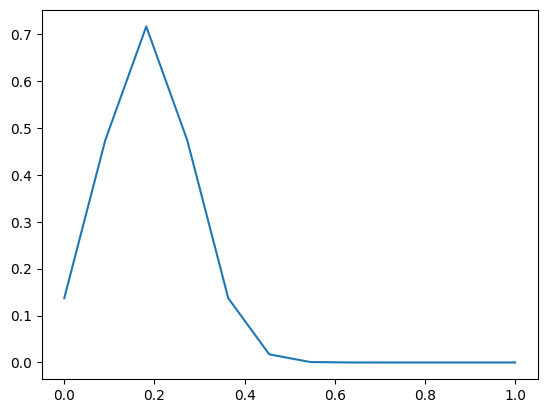

In [42]:
gaussian_dist = np.zeros(N, dtype=np.complex64)
# Initialize to Gaussian
for i in range(N):
    gaussian_dist[i] = np.exp(-0.5 * ((i / (N-1) - mu) / sigma) ** 2)
gaussian_dist /= np.linalg.norm(gaussian_dist)
plt.plot(x, gaussian_dist)
plt.show()

In [43]:
if use_real_machine:
    run_advection(N, T, c, R, r, num_time_points, num_shots, device, SAVE_DIR, use_real_machine, qpu_job_ids_filename, encoding=encoding)
else:
    run_advection(N, T, c, R, r, num_time_points, num_shots, device, SAVE_DIR, use_real_machine, sim_job_ids_filename, encoding=encoding, use_noisy_sim=False)
    run_advection(N, T, c, R, r, num_time_points, num_shots, device, SAVE_DIR, use_real_machine, noisy_sim_job_ids_filename, encoding=encoding, use_noisy_sim=True)

Unitless time:  0.000
1q gates: 13, 2q gates: 20
Saving in experiment_data/advection/db9165de60bb807bc8c39c3f8999fb13
Job id: d6678a8a-253d-494f-aaf3-30918de520a5
Unitless time:  0.133
1q gates: 13, 2q gates: 156
Saving in experiment_data/advection/db9165de60bb807bc8c39c3f8999fb13
Job id: 9ba5898e-6656-454b-8523-62b73531784e
Unitless time:  0.267
1q gates: 13, 2q gates: 156
Saving in experiment_data/advection/db9165de60bb807bc8c39c3f8999fb13
Job id: b87878af-6345-4282-a390-1c8f2ce3f094
Unitless time:  0.400
1q gates: 13, 2q gates: 156
Saving in experiment_data/advection/db9165de60bb807bc8c39c3f8999fb13
Job id: ca32c403-5261-4e3f-853c-23336159e1f7
Unitless time:  0.533
1q gates: 13, 2q gates: 156
Saving in experiment_data/advection/db9165de60bb807bc8c39c3f8999fb13
Job id: b02176bd-1755-41f3-96d0-ead5d95e88ec
Unitless time:  0.667
1q gates: 13, 2q gates: 156
Saving in experiment_data/advection/db9165de60bb807bc8c39c3f8999fb13
Job id: 1f2baf88-a89b-47ae-93d6-2beb95f961d5
Unitless time:  0

Get tasks

In [44]:
sim_freq = get_results(join(SAVE_DIR, sim_job_ids_filename), num_time_points, codewords)
noisy_sim_freq = get_results(join(SAVE_DIR, noisy_sim_job_ids_filename), num_time_points, codewords)

Getting job: d6678a8a-253d-494f-aaf3-30918de520a5
Job status: completed
Getting job: 9ba5898e-6656-454b-8523-62b73531784e
Job status: completed
Getting job: b87878af-6345-4282-a390-1c8f2ce3f094
Job status: completed
Getting job: ca32c403-5261-4e3f-853c-23336159e1f7
Job status: completed
Getting job: b02176bd-1755-41f3-96d0-ead5d95e88ec
Job status: completed
Getting job: 1f2baf88-a89b-47ae-93d6-2beb95f961d5
Job status: completed
Getting job: 4399f891-0f60-458e-a3fd-bbb06e40d03f
Job status: completed
Getting job: 413d02a4-96c6-4081-bb80-112fe5f4be67
Job status: completed
Getting job: 1ba23edf-f4c9-4886-99bc-eb3060060561
Job status: completed
Getting job: 0acdf159-a076-44b1-955e-d3622ce7b108
Job status: completed
Getting job: 85072a4c-d8ad-437a-ad64-68bdea6093ea
Job status: completed
Getting job: 37a16fed-9525-4acc-9fc7-76e168b92b7c
Job status: completed
Getting job: 30815471-8525-4365-9db5-f60d8bd7a542
Job status: completed
Getting job: f32e5dc1-2722-42aa-b94a-9d3c802e733c
Job status: co

In [45]:
# ionq_freq = get_results(join(SAVE_DIR, qpu_job_ids_filename), num_time_points, codewords)

Figures and post processing

In [46]:
sim_freq_normalized = np.zeros_like(sim_freq)
for i in range(num_time_points):
    if np.sum(sim_freq[i]) > 0:
        sim_freq_normalized[i] = sim_freq[i] / np.sum(sim_freq[i])

noisy_sim_freq_normalized = np.zeros_like(noisy_sim_freq)
for i in range(num_time_points):
    if np.sum(noisy_sim_freq[i]) > 0:
        noisy_sim_freq_normalized[i] = noisy_sim_freq[i] / np.sum(noisy_sim_freq[i])

# ionq_freq_normalized = np.zeros_like(ionq_freq)
# for i in range(num_time_points):
#     if np.sum(ionq_freq[i]) > 0:
#         ionq_freq_normalized[i] = ionq_freq[i] / np.sum(ionq_freq[i])

# num_samples_subspace_ionq = np.sum(ionq_freq, axis=1) * num_shots

In [48]:
sim_exp_val = sim_freq @ x
noisy_sim_exp_val = noisy_sim_freq_normalized @ x

Ground truth

In [49]:
def linear_transport(N, T, c, num_time_points, R, mu, sigma):
    psi_0 = np.zeros(N, dtype=np.complex64)
    # psi_0[1] = 1
    # Initialize to Gaussian
    for i in range(N):
        psi_0[i] = np.exp(-0.5 * ((i / (N-1) - mu) / sigma) ** 2)
    # for i in range(N):
    #     psi_0[i] = comb(n, i)
    psi_0 /= np.linalg.norm(psi_0)

    dx = R / (N - 1)

    H = diags([-1j * np.ones(N-1), 1j * np.ones(N-1)], [1, -1]).tocsc()
    H[0,0] = 0
    H[-1,-1] = 0
    # H[0,-1] = 1j
    # H[-1,0] = -1j

    
    x = np.linspace(0, T, N-1)

    H *= (c / (2 * dx))
    psi = expm_multiply(-1j * H, psi_0, start=0, stop=T, num=num_time_points)

    return psi

In [50]:

psi = linear_transport(N, T, c, num_time_points, R, mu, sigma)

ideal_dist = np.abs(psi) ** 2
x = np.linspace(0, 1, N)

ideal_exp_val = ideal_dist @ x


/home/jli0108/anaconda3/envs/hamiltonian-embedding/lib/python3.10/site-packages/scipy/sparse/_index.py:100: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil_matrix is more efficient.
  self._set_intXint(row, col, x.flat[0])


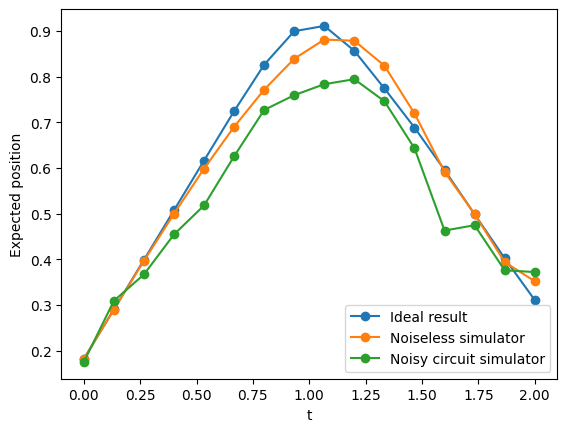

In [51]:
plt.plot(t_vals, ideal_exp_val, '-o', label="Ideal result")
plt.plot(t_vals, sim_exp_val, '-o', label="Noiseless simulator")
plt.plot(t_vals, noisy_sim_exp_val, '-o', label="Noisy circuit simulator")
plt.xlabel("t")
plt.ylabel("Expected position")
plt.legend()
plt.show()

In [52]:
# np.savez(join(SAVE_DIR, "data.npz"), 
#          ideal_dist=ideal_dist,                                         # Ideal QW
#          sim_freq=sim_freq,                                             # Simulator with Hamiltonian embedding
#          ionq_freq_normalized=ionq_freq_normalized,                     # IonQ (normalized)
#          propagation_distance_ideal=propagation_distance_ideal,         # Propagation distance
#          propagation_distance_sim=propagation_distance_sim,
#          propagation_distance_ionq=propagation_distance_ionq,
#          propagation_distance_ionq_err=propagation_distance_ionq_err,   # Propagation distance std error
#          ionq_freq=ionq_freq,                                           # IonQ frequency (unnormalized)
#          num_samples_subspace_ionq=num_samples_subspace_ionq)           # Samples in encoding subspace

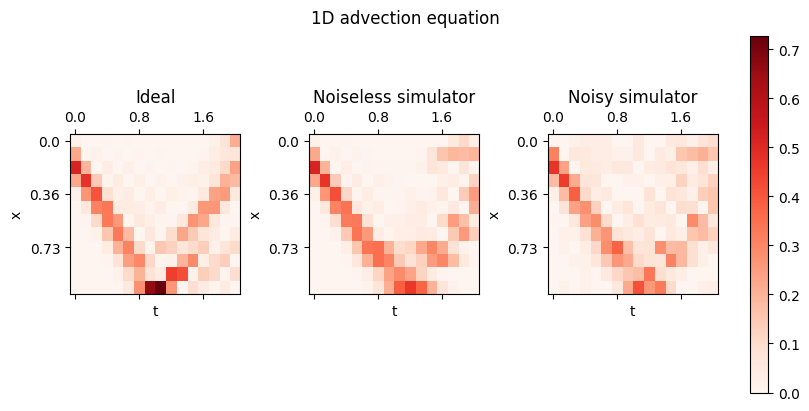

In [58]:
labels = ["Ideal", "Noiseless simulator", "Noisy simulator"]#, "IonQ"]

fig, axs = plt.subplots(1, len(labels), constrained_layout=True, facecolor="white", figsize=(8,4))

max_prob = max(np.max(ideal_dist), np.max(sim_freq_normalized), np.max(noisy_sim_freq_normalized))#, np.max(ionq_freq_normalized))
im = axs[0].matshow(ideal_dist.T, vmin=0, vmax=max_prob, cmap='Reds')
axs[1].matshow(sim_freq_normalized.T, vmin=0, vmax=max_prob, cmap='Reds')
axs[2].matshow(noisy_sim_freq_normalized.T, vmin=0, vmax=max_prob, cmap='Reds')
# axs[2].matshow(ionq_freq_normalized.T, vmin=0, vmax=max_prob)

aspect = 1.25
for i in range(len(labels)):
    axs[i].set_aspect(aspect)
    
    axs[i].set_ylabel("x")
    axs[i].set_yticks(np.arange(ideal_dist.shape[1])[::4])
    axs[i].set_yticklabels([str(round(float(label), 2)) for label in x[::4]])
    axs[i].set_title(labels[i])

    axs[i].set_xlabel("t")
    axs[i].set_xticks(np.arange(ideal_dist.shape[0])[::6])
    axs[i].set_xticklabels([str(round(float(label), 3)) for label in t_vals[::6]])

fig.colorbar(im, ax=axs.ravel().tolist())
fig.suptitle("1D advection equation")
plt.show()

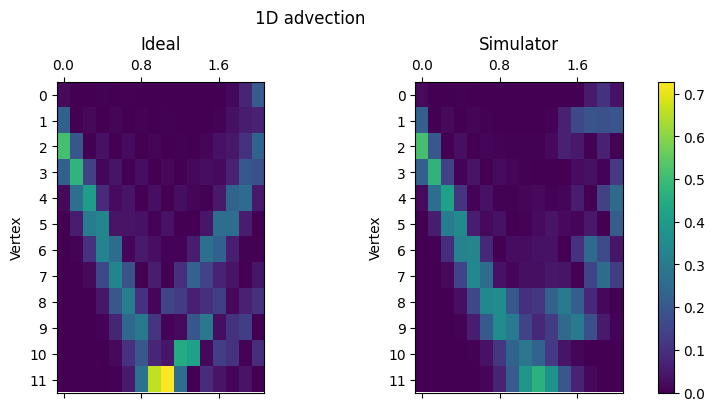

In [54]:
labels = ["Ideal", "Simulator"]#, "IonQ"]

fig, axs = plt.subplots(1, len(labels), constrained_layout=True, facecolor="white", figsize=(8,4))

max_prob = max(np.max(ideal_dist), np.max(sim_freq_normalized))#, np.max(ionq_freq_normalized))
im = axs[0].matshow(ideal_dist.T, vmin=0, vmax=max_prob)
axs[1].matshow(sim_freq_normalized.T, vmin=0, vmax=max_prob)
# axs[2].matshow(ionq_freq_normalized.T, vmin=0, vmax=max_prob)

aspect = 2

for i in range(len(labels)):
    axs[i].set_aspect(aspect)
    
    axs[i].set_ylabel("Vertex")
    axs[i].set_yticks(np.arange(ideal_dist.shape[1])[::1])
    axs[i].set_yticklabels(np.arange(ideal_dist.shape[1])[::1])
    axs[i].set_title(labels[i])

    axs[i].set_xticks(np.arange(ideal_dist.shape[0])[::6])
    axs[i].set_xticklabels([str(round(float(label), 3)) for label in t_vals[::6]])

fig.colorbar(im, ax=axs.ravel().tolist())
fig.suptitle("1D advection")
plt.show()